In [3]:
# 1] Data Exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('diabetes.csv')
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std    

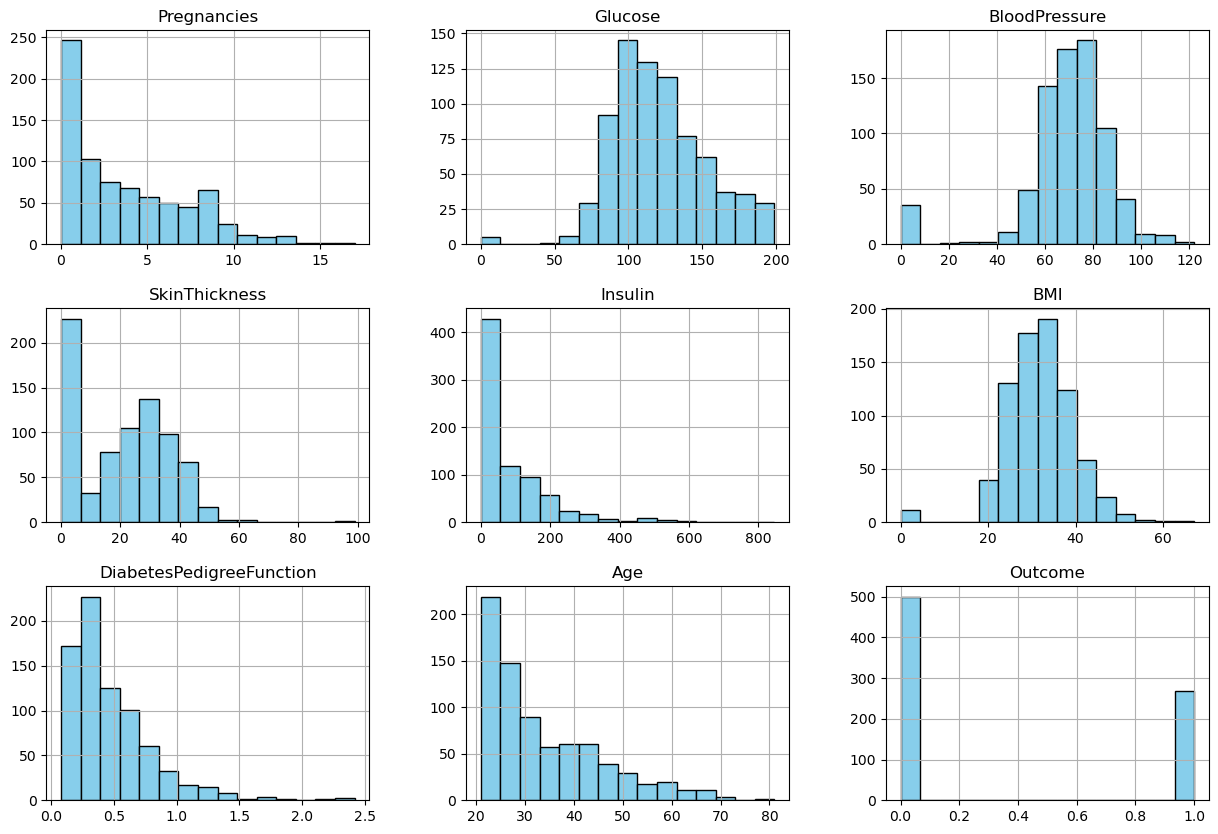

In [4]:
df.hist(bins=15, figsize=(15,10), color='skyblue', edgecolor='black')
plt.title('Outcome')
plt.show()

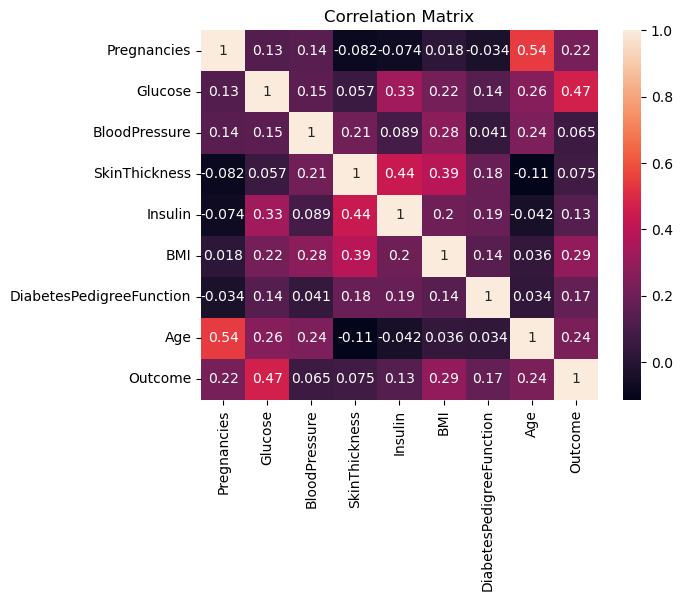

In [5]:
corr = df.corr()
sns.heatmap(corr, annot=True,)
plt.title('Correlation Matrix')
plt.show()

In [6]:
#No missing values, but several zero values existed in major columns like Glucose, BloodPressure etc. Hence they are handled with median replacement.
#Features such as Glucose, BMI, and Age are most influential for diabetes prediction.

In [7]:
# 2] Data Preprocessing

In [8]:
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in columns_with_zeros:
    print(f'{col} has {sum(df[col] == 0)} zeros')

Glucose has 5 zeros
BloodPressure has 35 zeros
SkinThickness has 227 zeros
Insulin has 374 zeros
BMI has 11 zeros


In [9]:
df[columns_with_zeros] = df[columns_with_zeros].replace(0, np.nan)
df[columns_with_zeros] = df[columns_with_zeros].fillna(df[columns_with_zeros].median())

In [10]:
# There are no categorial columns in dataset. Hence no encoding is required.

In [11]:
# 3] Model Building

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [13]:
# 4] Model Evaluations

In [14]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report)
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
print("Model Evaluation Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Model Evaluation Metrics:
Accuracy:  0.7532
Precision: 0.6667
Recall:    0.6182
F1-Score:  0.6415
ROC-AUC:   0.8211


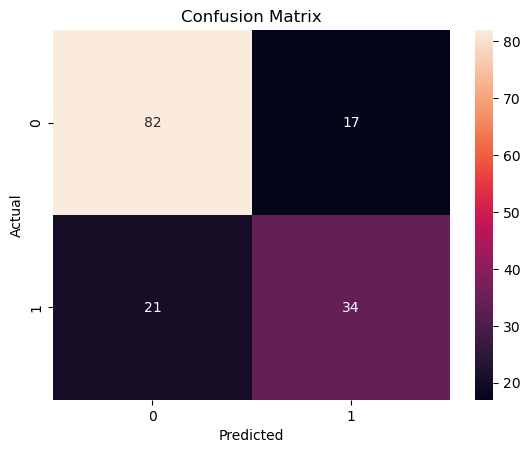

In [16]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

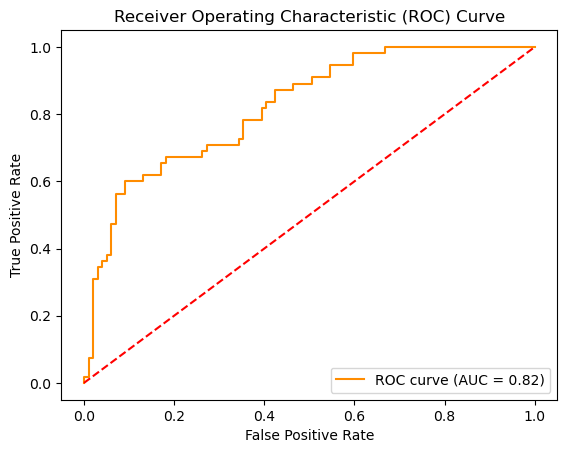

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [18]:
# 5] Interpretation

In [19]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)

                    Feature  Coefficient
6  DiabetesPedigreeFunction     0.553449
5                       BMI     0.101791
0               Pregnancies     0.067588
1                   Glucose     0.037337
7                       Age     0.034615
3             SkinThickness     0.007712
4                   Insulin    -0.001668
2             BloodPressure    -0.013239


In [20]:
# From the coefficient values, the most influential predictors in this dataset are:
# 1)DiabetesPedigreeFunction — The most significant feature. Individuals with a strong family history of diabetes are much more likely to be diabetic.
# 2)BMI — Plays an important role as obesity is a well-known risk factor for diabetes.
# 3)Pregnancies — Slightly contributes to increased diabetes likelihood.
# 4)Glucose & Age — Have small but positive effects on diabetes probability.
# 5)Insulin, BloodPressure, and SkinThickness — Show weak or negligible predictive power in this dataset.

In [21]:
# 1. What is the difference between Precision and Recall?
# ---> Precision focuses on the quality of positive predictions (avoiding false alarms).
# ---> Recall focuses on the completeness of positive predictions (catching all actual positives).
# 2. What is Cross-Validation, and why is it important in binary classification?
# --->Cross-Validation is a technique used to evaluate how well a model generalizes to unseen data.
# ---> Provides a more reliable estimate of model performance than a single train-test split.
# ---> Reduces overfitting by ensuring the model is tested on multiple unseen subsets.
# ---> Helps select the best model and hyperparameters (e.g., using GridSearchCV).

In [24]:
# 6] Deployment

In [23]:
import joblib
joblib.dump(log_reg, 'diabetes_model.pkl')

['diabetes_model.pkl']